In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import transformers
from transformers import  DNATokenizer

%matplotlib inline

/p/project1/hai_dnaori/piroozeh1/venv_dnabert/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Visualize attention scores for test set with matrix representation for finetuned model on Rand_Neg dataset
data_dir="/data/OriDB_random_neg/train_dev_test_oridb"

data = pd.read_csv(os.path.join(data_dir,"test_window.tsv"), sep='\t', header=0)

print(data.head())


   chr    start      end                                                seq  \
0   13   363312   363811  ATGCATTACAAATTTGTATTTGATTCTATATATAGTTTCGTTATAT...   
1    4   483669   484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
2    7  1056150  1056649  CCTTGTAGTTGTCCTGCAAAGATGGGTAGGTATTTTCCTTGATATG...   
3   15   766442   766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
4    4   638559   639058  CTCTAACTAATACAAACTCCTTACTATCTAATATAACGGCTACATC...   

   label  
0      0  
1      1  
2      0  
3      1  
4      0  


In [ ]:
prob  = np.load("/data/OriDB_random_neg/train_dev_test_oridb/4/test_res/pred_results.npy")
Predictions=(prob >= 0.5).astype(int)
data['pred'] = Predictions
data.head

<bound method NDFrame.head of      chr    start      end                                                seq  \
0     13   363312   363811  ATGCATTACAAATTTGTATTTGATTCTATATATAGTTTCGTTATAT...   
1      4   483669   484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
2      7  1056150  1056649  CCTTGTAGTTGTCCTGCAAAGATGGGTAGGTATTTTCCTTGATATG...   
3     15   766442   766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
4      4   638559   639058  CTCTAACTAATACAAACTCCTTACTATCTAATATAACGGCTACATC...   
..   ...      ...      ...                                                ...   
125   10    18014    18513  AGTAAAACTCTTGTGTCTTTTCATCGAACGTCCATGCAGAACCACC...   
126   16   698214   698713  TAAGCTCTGAGGGGCTTAATACTGTTGGTAAGACTCCAGAAATCGT...   
127   16   339219   339718  CTGGACCGCCCGGTAAGTTCTGCTATTAACAAATTAAATAAAATTG...   
128    4  1252944  1253443  AGAGGTCATTGTTCAAAGTGAGTTGGTGAGTTTTGGTCGGATACCC...   
129    8   555958   556457  ACATAACTGAATGTTAAAATGGCATCATCAATACAGTATTACTGAT...  

In [4]:
true_positives = data[(data['label'] == 1) & (data['pred'] == 1)]
print(len(true_positives))
true_positives.head(5)

53


,chr,start,end,seq,label,pred
1,4,483669,484168,TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...,1,1
3,15,766442,766941,CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...,1,1
6,15,337119,337618,AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...,1,1
7,7,607176,607675,AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...,1,1
12,6,256090,256589,GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...,1,1


In [5]:

def format_attention(attention):
    squeezed = []
    for layer_attention in attention:
        # 1 x num_heads x seq_len x seq_len
        if len(layer_attention.shape) != 4:
            raise ValueError("The attention tensor does not have the correct number of dimensions. Make sure you set "
                             "output_attentions=True when initializing your model.")
        squeezed.append(layer_attention.squeeze(0))
    # num_layers x num_heads x seq_len x seq_len
    return torch.stack(squeezed)

def get_attention_dna(model, tokenizer, sentence_a, start, end):
    inputs = tokenizer.encode_plus(sentence_a, sentence_b=None, return_tensors='pt', add_special_tokens=True)
    input_ids = inputs['input_ids']
    output = model(input_ids)
    attention = output[-1]
    logits = output[0]
    pred=logits.detach().numpy()
    softmax = np.exp(pred) / np.sum(np.exp(pred), axis=1, keepdims=True)
    # print("prediction: ")
    # print(pred)
    print("softmax: ", softmax)
    input_id_list = input_ids[0].tolist() # Batch index 0
    tokens = tokenizer.convert_ids_to_tokens(input_id_list) 
    # print("tokens: ", tokens)
    attn = format_attention(attention)
    attn_score = []
    for i in range(1, len(tokens)-1):
        attn_score.append(float(attn[start:end+1,:,0,i].sum()))
    
    matrix_attention_scores = np.zeros([len(tokens), len(tokens)])
    for i in range(0, len(tokens)):
        for j in range(0, len(tokens)):
            matrix_attention_scores[i][j] = float(attn[end,:,i,j].sum())

    return attn_score, matrix_attention_scores

def get_real_score(attention_scores, kmer, metric):
    counts = np.zeros([len(attention_scores)+kmer-1])
    real_scores = np.zeros([len(attention_scores)+kmer-1])

    if metric == "mean":
        for i, score in enumerate(attention_scores):
            for j in range(kmer):
                counts[i+j] += 1.0
                # real_scores[i+j] += score
                real_scores[i+j] += score[0]  # Extract a single element from the score array


        real_scores = real_scores/counts
    else:
        pass

    return real_scores

# SEQUENCE = "TGCCTGGCTTTTTGTAATTTTTGAAGAGACGGGGTTTTGCCATGATG"


In [6]:
def seq2kmer(seq, k):
      
        kmer = [seq[x:x+k] for x in range(len(seq)+1-k)]
        kmers = " ".join(kmer)
        return kmers

In [7]:
def Visualize(kmer, model_path, start_layer, end_layer, metric, sequence):
    
        # load model and calculate attention
    tokenizer_name = 'dna' + str(kmer)
    model_path = model_path
    model = transformers.BertForSequenceClassification.from_pretrained(model_path, output_attentions=True)
    tokenizer = DNATokenizer.from_pretrained(tokenizer_name, do_lower_case=False)
    raw_sentence = sequence 
    sentence_a = seq2kmer(raw_sentence, kmer)
   
   
    attention, atten_matrix = get_attention_dna(model, tokenizer, sentence_a, start=start_layer, end=end_layer)
    
    attention_scores = np.array(attention).reshape(np.array(attention).shape[0],1)
    
    # attention_scores[0] = 0
    
    real_scores = get_real_score(attention_scores, kmer, metric)
    scores = real_scores.reshape(1, real_scores.shape[0])


 
    # plot        
    # sns.set_theme()
    # ax = sns.heatmap(scores, cmap='YlGnBu', vmin=0)
    # plt.show()
    return scores, atten_matrix

    

In [ ]:
original_origin=pd.read_csv("/data/yeast_oridb_confirmed_Less500.csv")
original_origin

,chr,start,end,name,length
0,1,30946,31184,"104,00 ARS",239
1,1,70258,70491,"106,00 ARS",234
2,1,124350,124599,"107,00 ARS",250
3,1,159906,160127,"109,00 ARS",222
4,1,176154,176402,"110,00 ARS",249
...,...,...,...,...,...
320,16,776921,777152,ARS1626.5,232
321,16,819153,819393,"1627,00 ARS",241
322,16,842646,842894,"1628,00 ARS",249
323,16,880854,881102,"1630,00 ARS",249


In [9]:
data['origin_start'] = np.nan
data['origin_end'] = np.nan

for index, row in data.iterrows():
    matching_rows = original_origin[(original_origin['chr'] == row['chr']) & (original_origin['start'] >= row['start']) & (original_origin['end'] <= row['end'])]
    if not matching_rows.empty:
        data.at[index, 'origin_start'] = matching_rows['start'].values[0]
        data.at[index, 'origin_end'] = matching_rows['end'].values[0]

data[data['label']==1].head(10)   

,chr,start,end,seq,label,pred,origin_start,origin_end
1,4,483669,484168,TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...,1,1,483846.0,484091.0
3,15,766442,766941,CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...,1,1,766617.0,766862.0
6,15,337119,337618,AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...,1,1,337279.0,337528.0
7,7,607176,607675,AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...,1,1,607176.0,607619.0
12,6,256090,256589,GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...,1,1,256263.0,256418.0
14,2,622494,622993,AGCCAAACTGAAAATTTCCGTTCACGATATTTGAATCTAGTGTTAG...,1,1,622625.0,622894.0
15,14,412206,412705,AGGAATAGATTAAAGAACACTATATATGCATAGCCACTTCAAAACG...,1,1,412263.0,412493.0
16,6,199107,199606,CGCACTCTAACTGGCATTTTAAAGAAAAAGGGATAAATGCAATGTT...,1,0,199382.0,199493.0
18,11,98190,98689,GACGGAGGGGGTGGGAAAAGGCTGAATGCAACCATTGTCACTAAGA...,1,1,98329.0,98568.0
20,7,231509,232008,TGTTCATTAATTTTTATGAACTTGACTTCATCCTACTTGGATTACA...,1,0,231909.0,231984.0


In [10]:
def plot_attention_scores(sample,scores,original_seq=True):
    sequence=sample['seq']
        
    start=sample['start']
    end=sample['end']
    if sample['label']==1:
        origin_start=int(sample['origin_start']-start)
        origin_end=  int(sample['origin_end']-start)



    plt.figure(figsize=(12, 4))
    plt.plot(range(len(sequence)), scores, marker='o', linestyle='-', color='b', markersize=2)
    if  sample['label']==1:
        plt.axvline(x=origin_start, color='red', linestyle='--', label='origin start and end')
        plt.axvline(x=origin_end, color='red', linestyle='--')

    plt.xlabel('Position in Sequence')
    plt.ylabel('Attention Scores')
    plt.title("Attention Scores Along DNA Sequence chr{}-{}-{}".format(str(sample['chr']), start, end))
             
    plt.legend()
    plt.show()


chr                                                     15
start                                               766442
end                                                 766941
seq      CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...
label                                                    1
pred                                                     1
Name: 3, dtype: object
<class 'transformers.tokenization_dna.DNATokenizer'>
softmax:  [[1.1738898e-05 9.9998826e-01]]
scores: (1, 500)
atten_matrix: (499, 499)
Minimum value: 4.424050459306272e-09
Maximum value: 3.6323227882385254


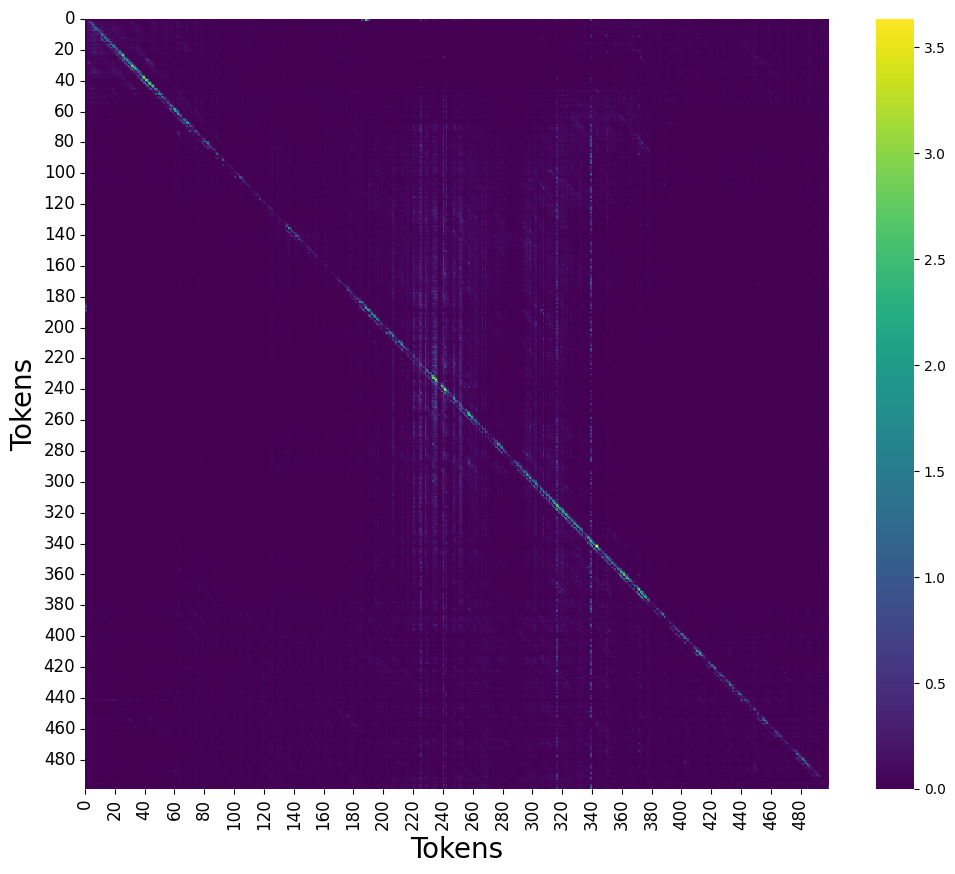

In [ ]:


kmer = 4
model_path = "/data/OriDB_random_neg/train_dev_test_oridb50/4/fine_tuned_model"
# model_path = "/p/project1/hai_dnaori/piroozeh1/yeast-origins/data/OriDB_random_neg/train_dev_test_oridb/4/model"
start_layer =11
end_layer = 11
metric = "mean"

sequence = true_positives.iloc[1]
print(sequence)


scores, atten_matrix=Visualize(kmer, model_path, start_layer, end_layer, metric, sequence["seq"])
print("scores:", scores.shape)
print("atten_matrix:", atten_matrix.shape)
attention_scores=scores.reshape(scores.shape[1],)

min_val = np.min(atten_matrix)
max_val = np.max(atten_matrix)

print(f"Minimum value: {min_val}")
print(f"Maximum value: {max_val}")



# plot_attention_scores(sequence, scores= attention_scores, original_seq=True) 




plt.figure(figsize=(12, 10))
sns.heatmap(atten_matrix,  cmap='viridis', vmin=0)

plt.xlabel('Tokens', fontsize=20)
plt.ylabel('Tokens', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=12)
n = atten_matrix.shape[0]
step = 20
ticks = np.arange(0, n, step)
plt.xticks(ticks, labels=ticks)
plt.yticks(ticks, labels=ticks)
plt.savefig("att_dnabert2_final.png", dpi=300, bbox_inches='tight')
plt.savefig("att_dnabert2_final.eps", dpi=300, bbox_inches='tight')
plt.show()


In [12]:
plt.savefig("att_dnabert2_final.png", dpi=300, bbox_inches='tight')
plt.savefig("att_dnabert2_final.eps", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>